In [14]:
import numpy as np

red = './reduru'
# Load input.npy file
input = np.load(red+'/input.npy')
# Load vm_pu_opt.npy
vm_pu_opt = np.load(red+'/vm_pu_opt.npy')

q_switch_shunt = np.load(red+'/q_switch_shunt_opt.npy')

print(input.shape)
print(vm_pu_opt.shape)
print(q_switch_shunt.shape)

[ Info: Julia version info


Julia Version 1.6.0
Commit f9720dc2eb (2021-03-24 12:55 UTC)
Platform Info:
  OS: Linux (x86_64-pc-linux-gnu)
      "Manjaro Linux"
  uname: Linux 6.6.30-2-MANJARO #1 SMP PREEMPT_DYNAMIC Wed May  8 17:46:43 UTC 2024 x86_64 unknown
  CPU: 13th Gen Intel(R) Core(TM) i5-13400F: 
                 speed         user         nice          sys         idle          irq
       #1-16  4492 MHz    2397910 s        435 s     218138 s   41604654 s      18423 s
       
  Memory: 62.63358688354492 GB (804.19140625 MB free)
  Uptime: 277099.0 sec
  Load Avg:  2.81  2.91  3.35
  WORD_SIZE: 64
  LIBM: libopenlibm
  LLVM: libLLVM-11.0.1 (ORCJIT, goldmont)
Environment:
  HOME = /home/iboero
  PATH = /home/iboero/miniconda3/envs/proy/bin:/home/iboero/.vscode-server/cli/servers/Stable-dc96b837cf6bb4af9cd736aa3af08cf8279f7685/server/bin/remote-cli:/home/iboero/miniconda3/envs/proy/bin:/home/iboero/miniconda3/condabin:/home/iboero/.local/bin:/usr/local/sbin:/usr/local/bin:/usr/bin:/opt/cuda/bin:/opt/cuda/nsi

[ Info: Julia executable: /home/iboero/julia/bin/julia
[ Info: Trying to import PyCall...
┌ Info: PyCall is already installed and compatible with Python executable.
│ 
│ PyCall:
│     python: /home/iboero/miniconda3/envs/proy/bin/python
│     libpython: /home/iboero/miniconda3/envs/proy/lib/libpython3.11.so.1.0
│ Python:
│     python: /home/iboero/miniconda3/envs/proy/bin/python
└     libpython: 


(19086, 107, 4)
(19086, 107, 1)
(19086, 107, 1)


In [2]:
# Concatenate two arrays
# output = np.concatenate((input, vm_pu_opt), axis=2)
output = np.concatenate((input, vm_pu_opt, q_switch_shunt), axis=2)

# Do train, test and validation split
np.random.shuffle(output)
train = output[0:int(output.shape[0]*0.77)]
val = output[int(output.shape[0]*0.77):int(output.shape[0]*0.93)]
test = output[int(output.shape[0]*0.93):]

In [8]:
# save train.npy
np.save(red+'/train/input.npy', train[:, :, :4])
np.save(red+'/train/vm_pu_opt.npy', train[:, :, 4:5])
np.save(red+'/train/q_switch_shunt_opt.npy', train[:, :, 5:6])
np.save(red+'/val/input.npy', val[:, :, :4])
np.save(red+'/val/vm_pu_opt.npy', val[:, :, 4:5])
np.save(red+'/val/q_switch_shunt_opt.npy', val[:, :, 5:6])
np.save(red+'/test/input.npy', test[:, :, :4])
np.save(red+'/test/vm_pu_opt.npy', test[:, :, 4:5])
np.save(red+'/test/q_switch_shunt_opt.npy', test[:, :, 5:6])

### Separando la data de Bonete

In [5]:
import numpy as np
import pandapower as pp

red = './reduru'
input = np.load(red+'/input.npy')

net = pp.from_pickle('/home/iboero/Tesis/supervised_uru/GNN4OPF/data/red_uru.p')

In [26]:
np.where(input[:, 100, 0] == 0)[0].shape

(2136,)

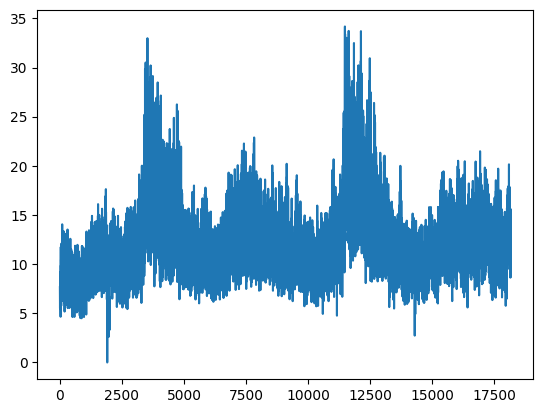

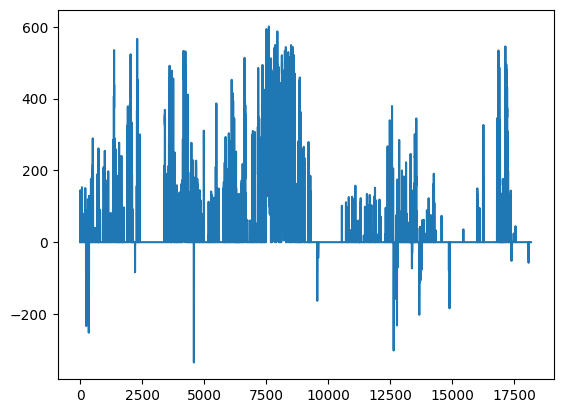

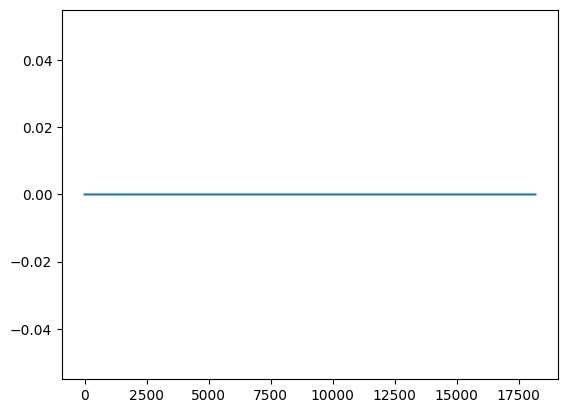

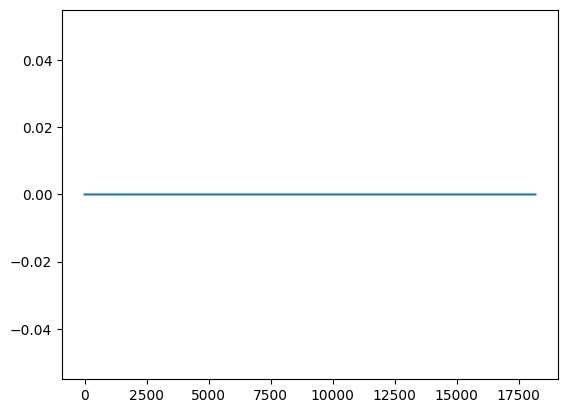

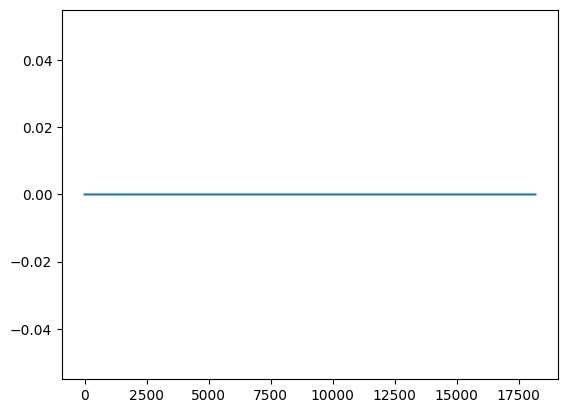

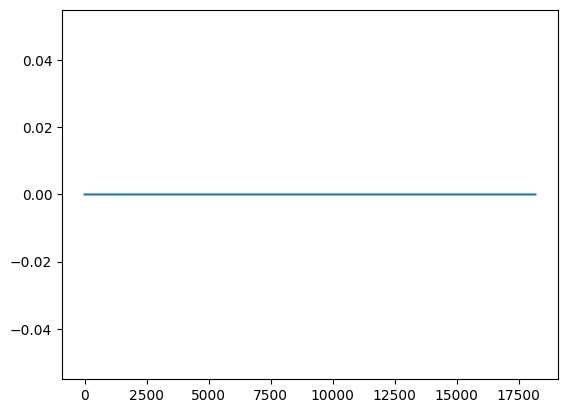

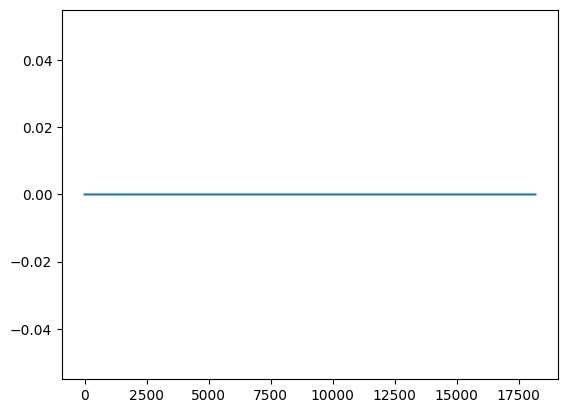

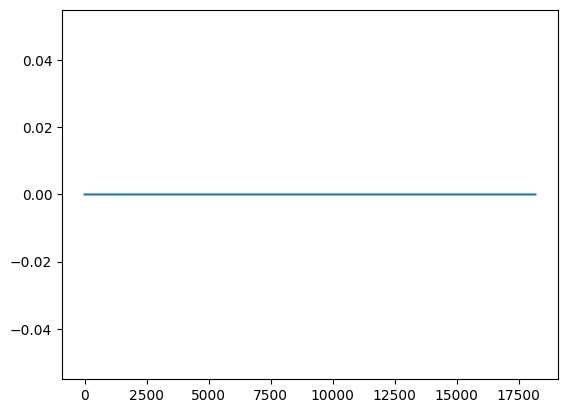

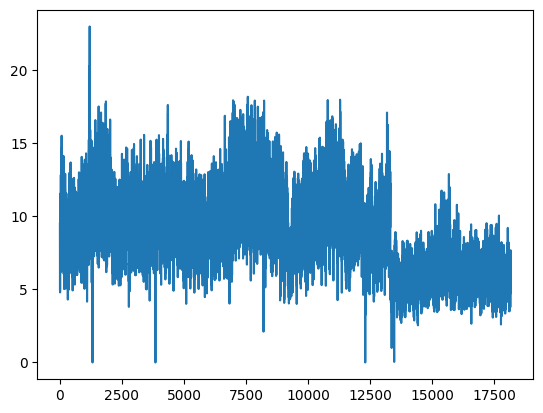

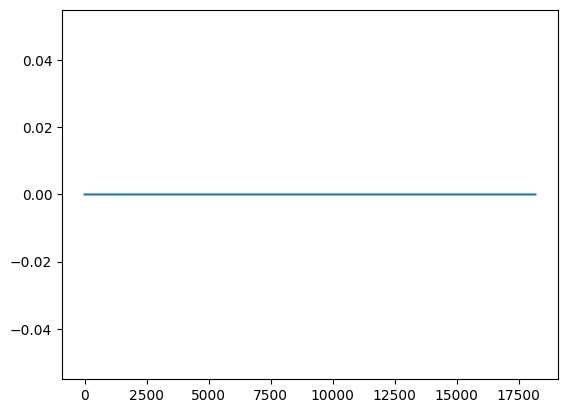

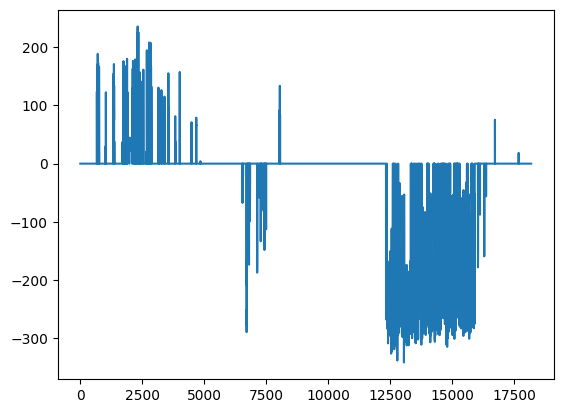

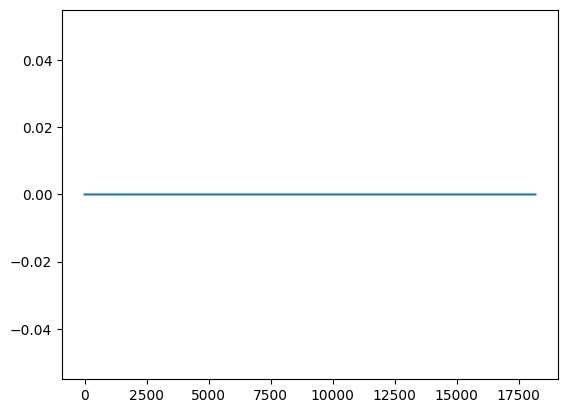

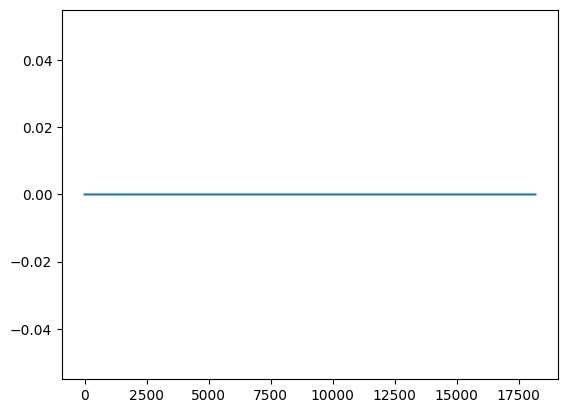

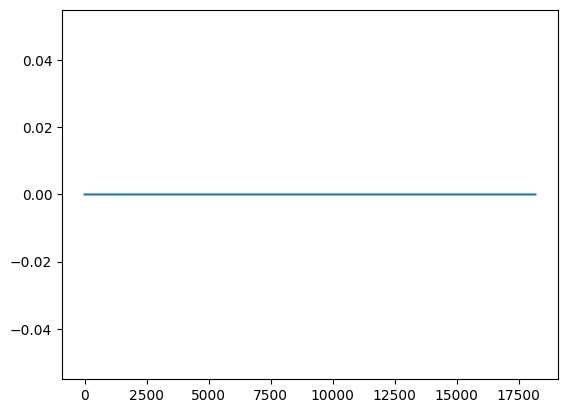

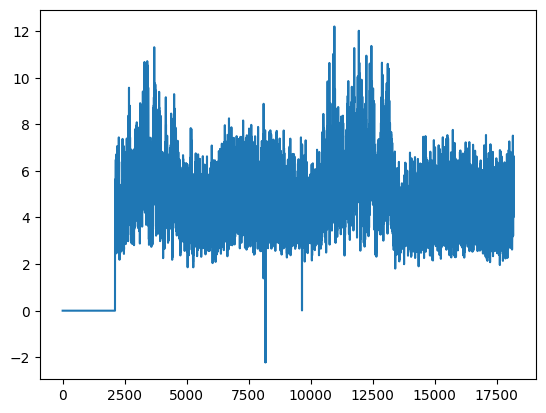

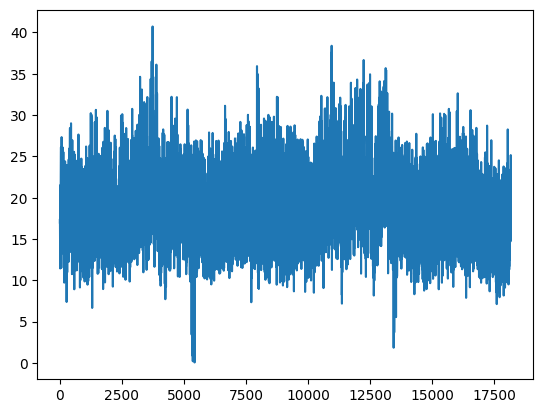

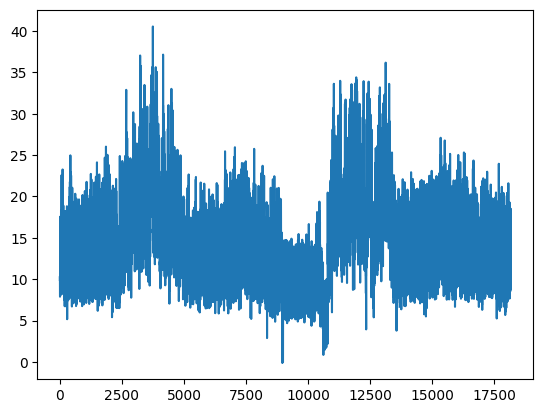

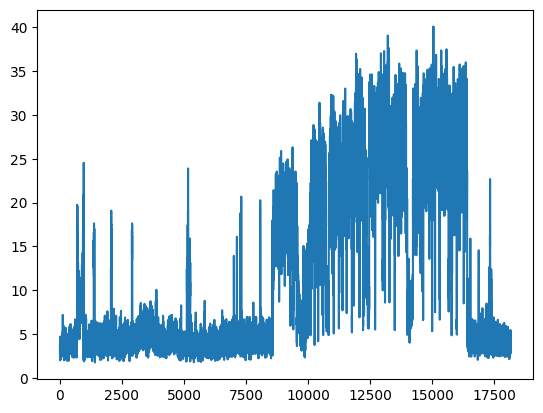

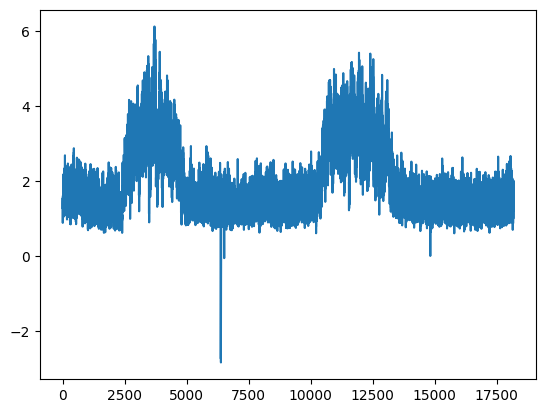

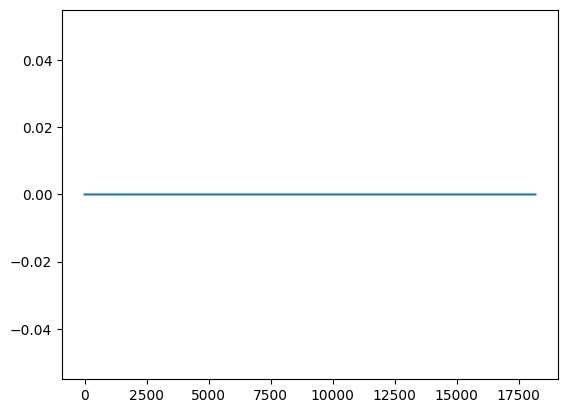

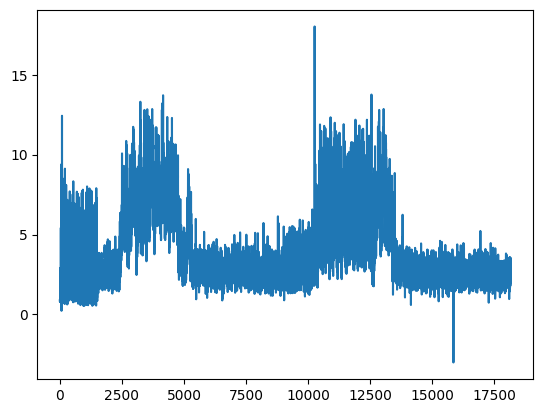

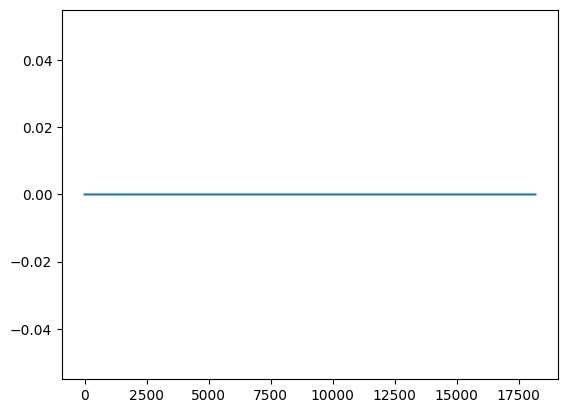

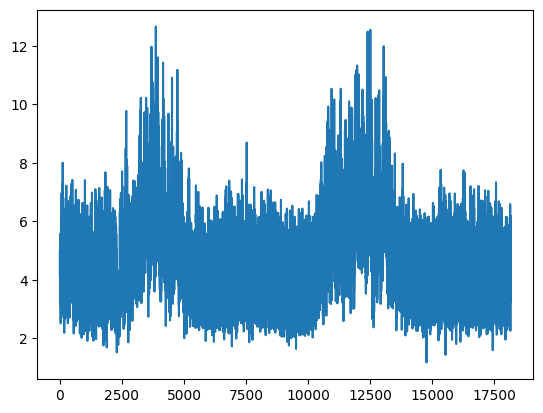

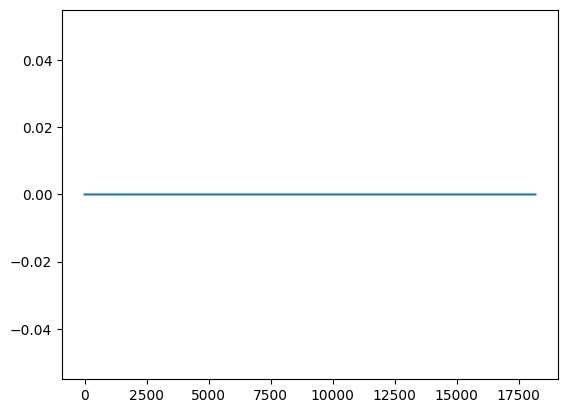

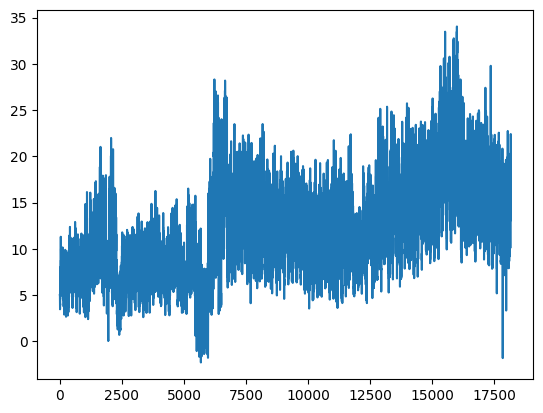

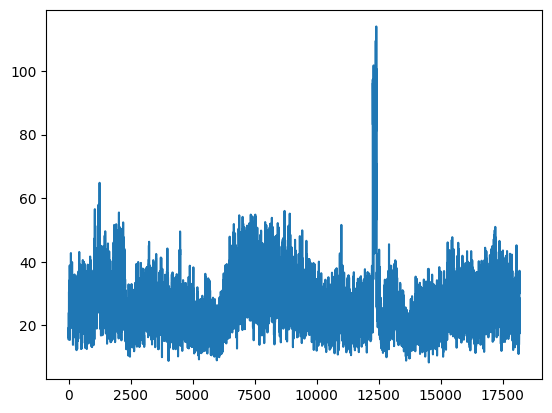

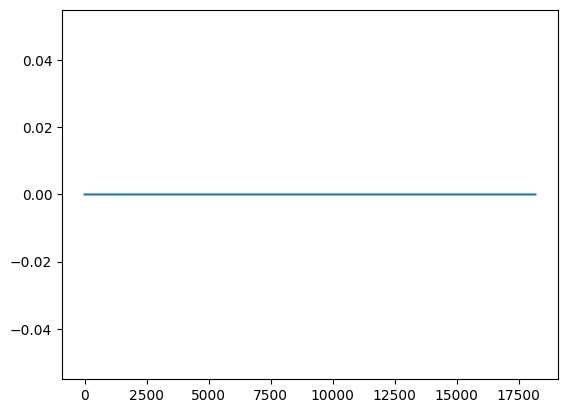

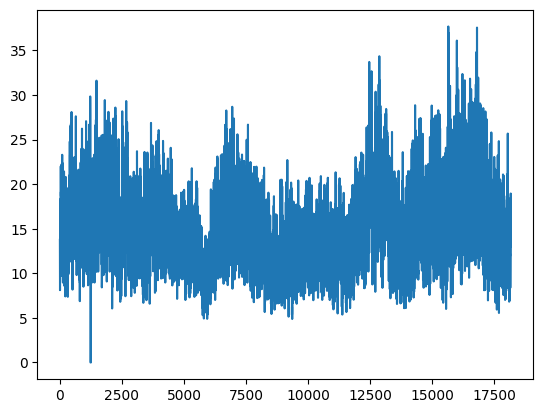

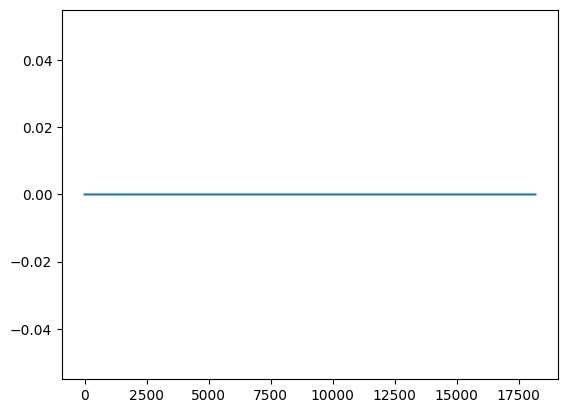

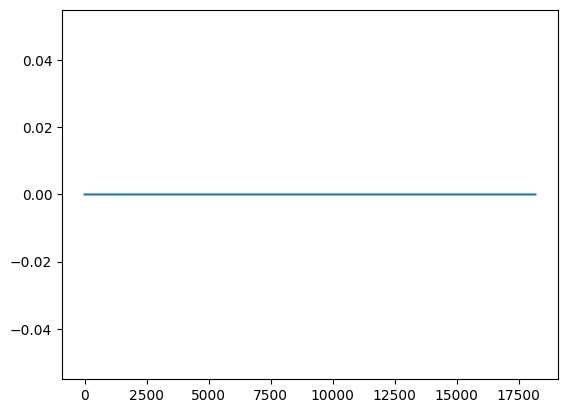

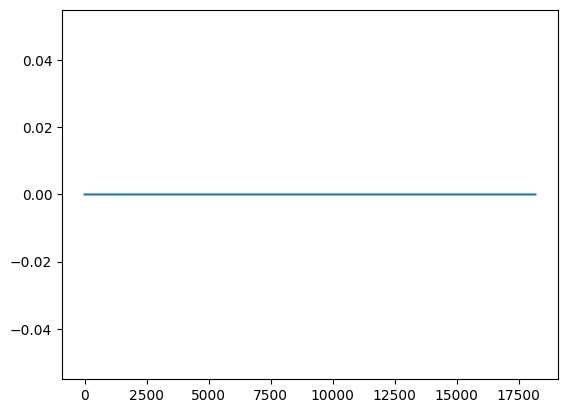

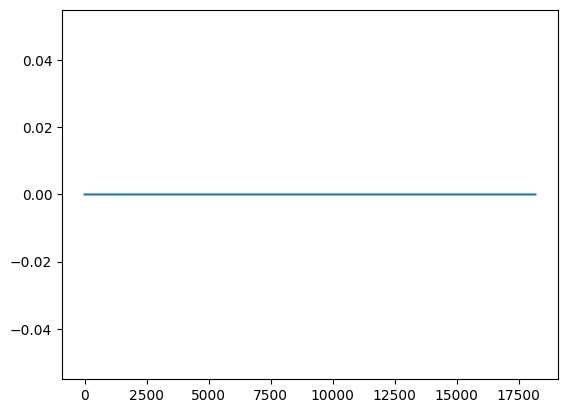

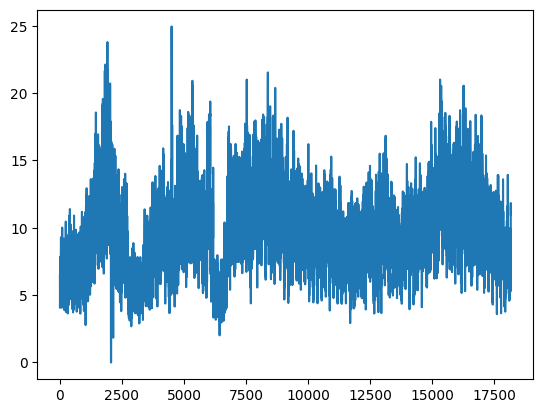

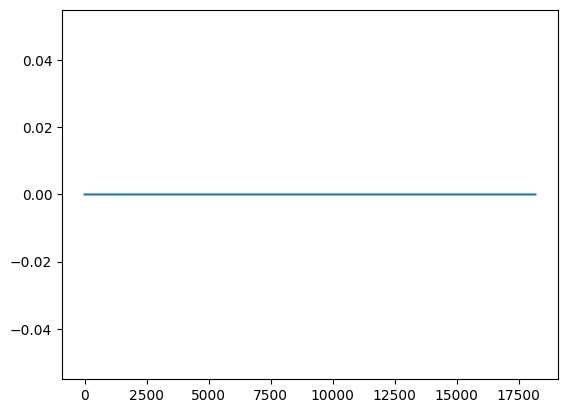

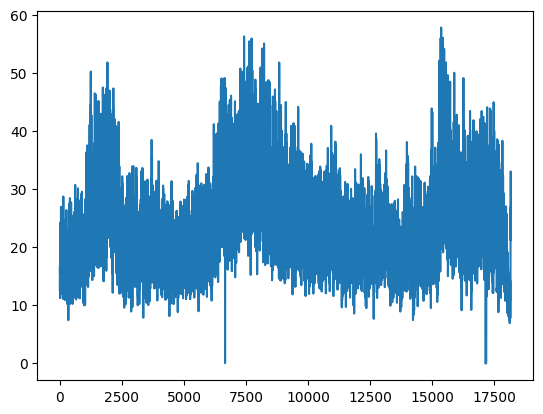

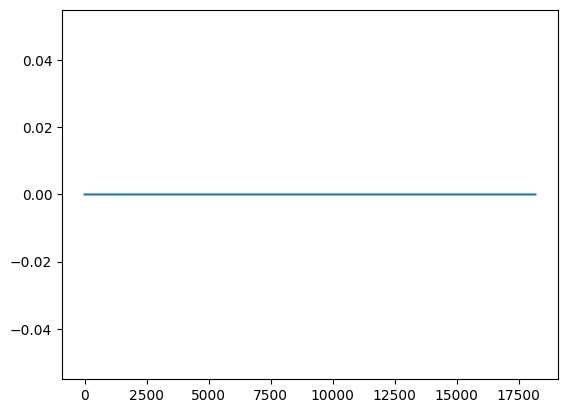

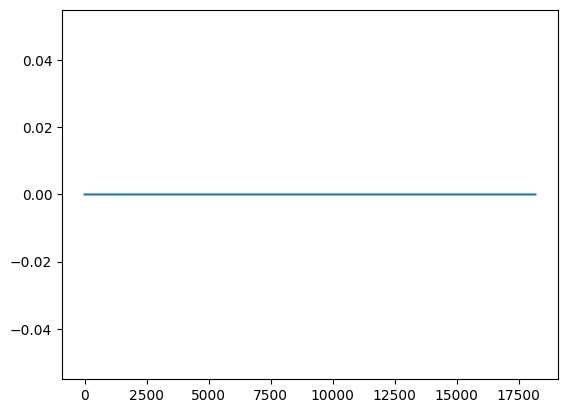

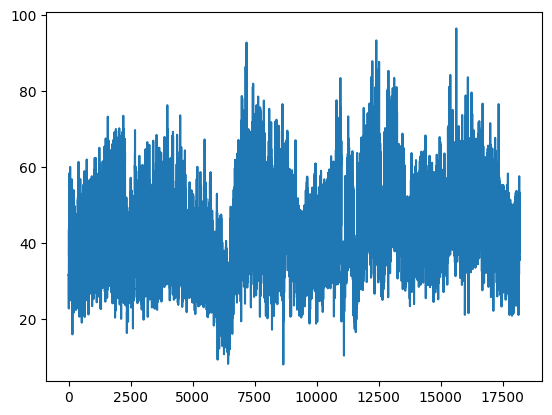

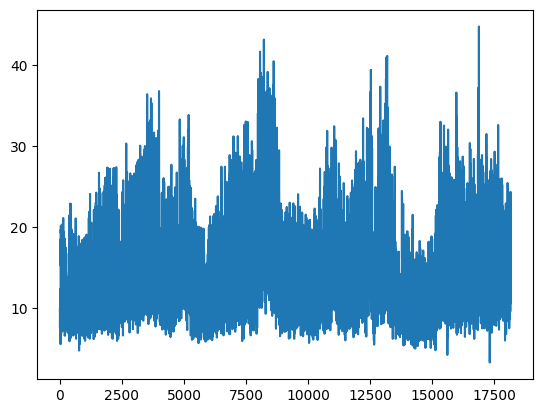

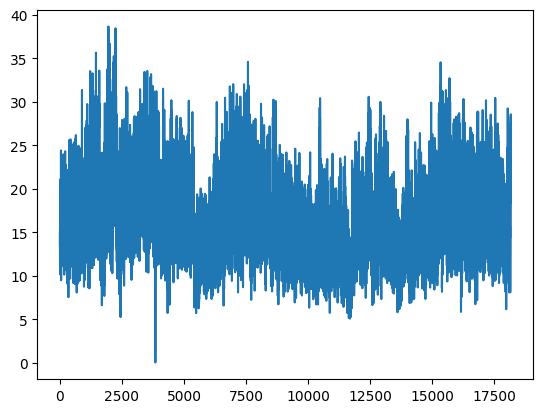

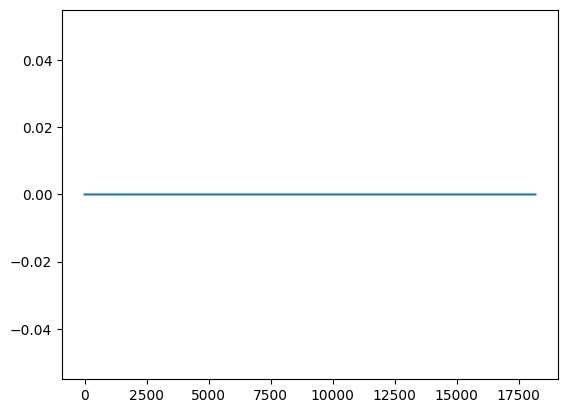

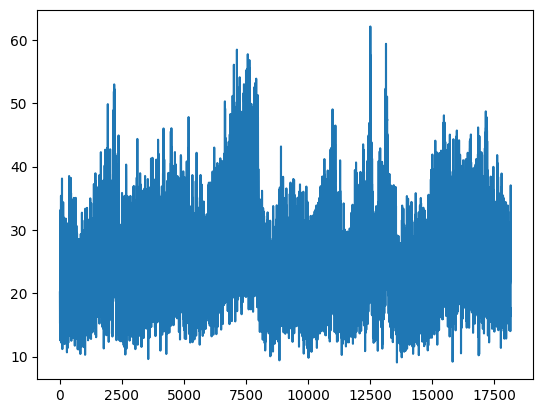

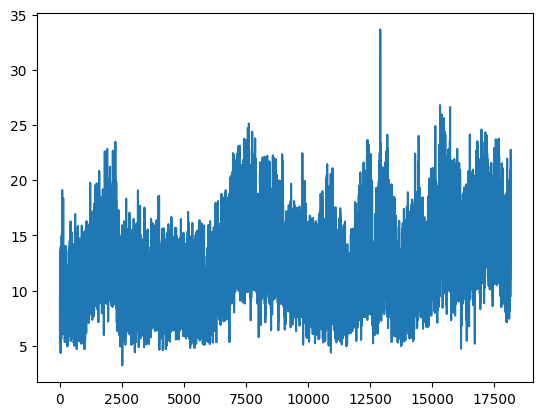

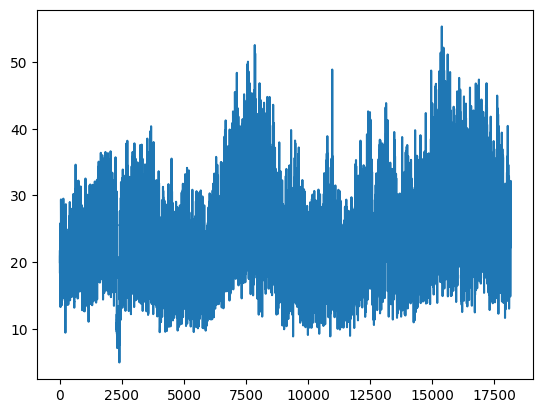

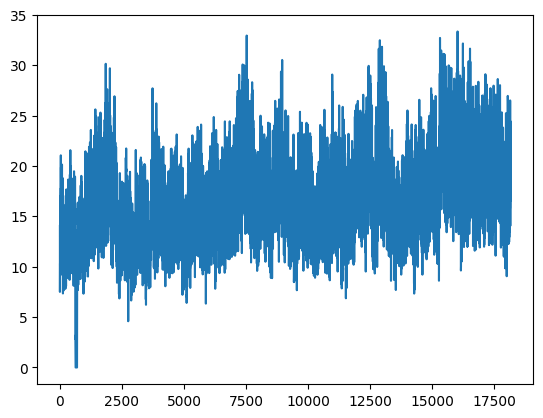

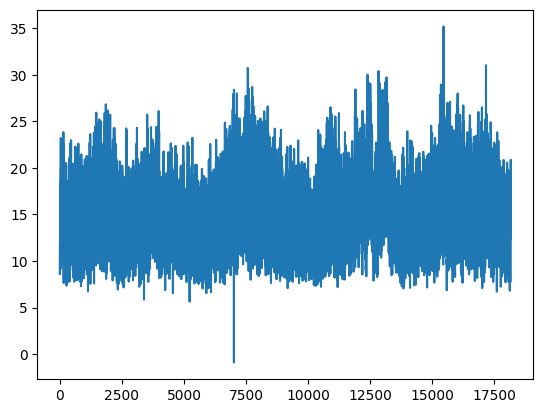

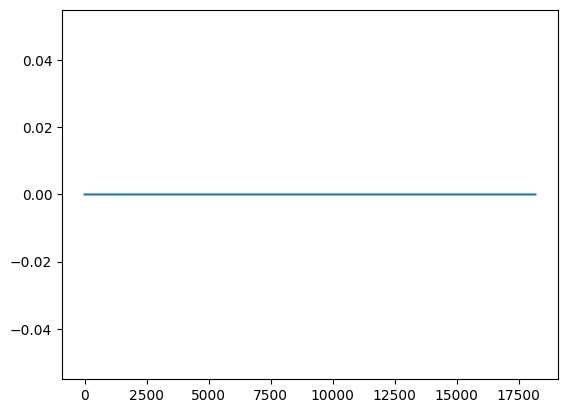

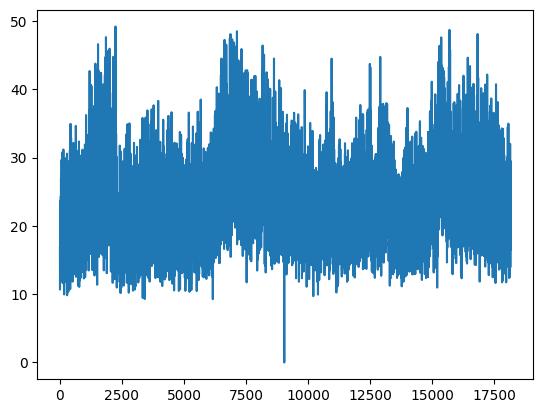

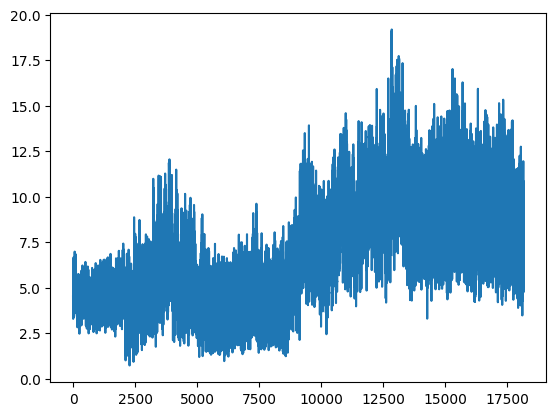

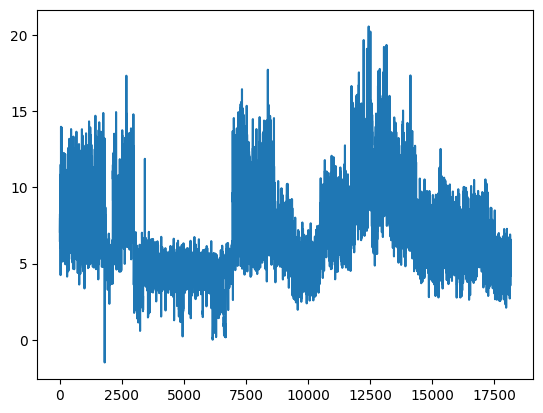

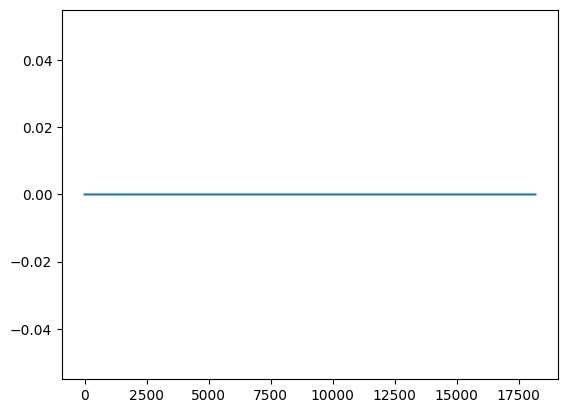

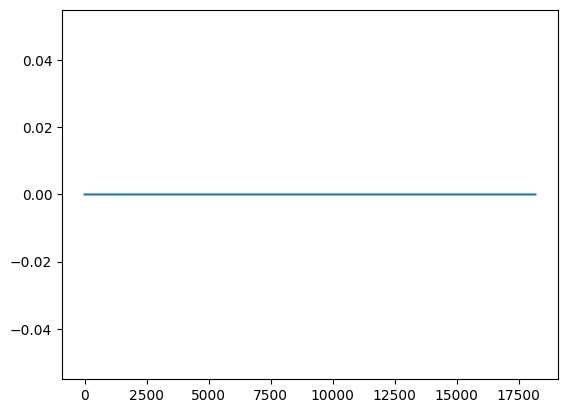

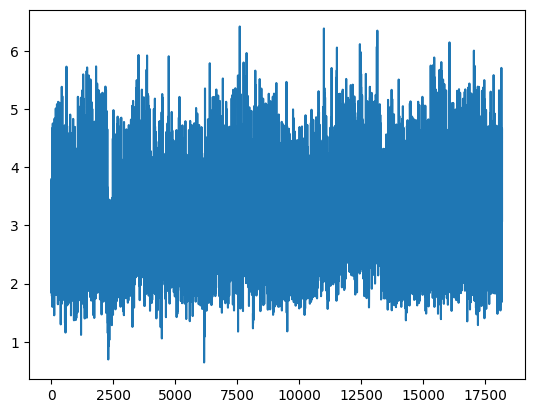

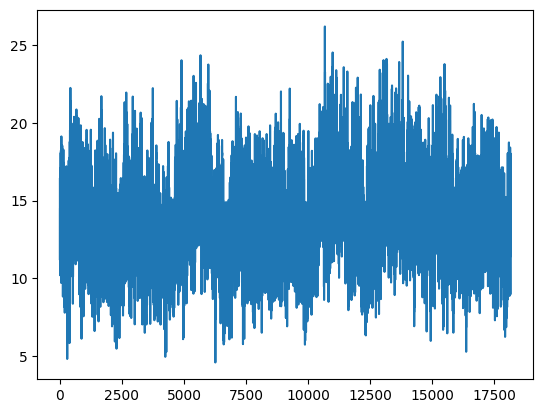

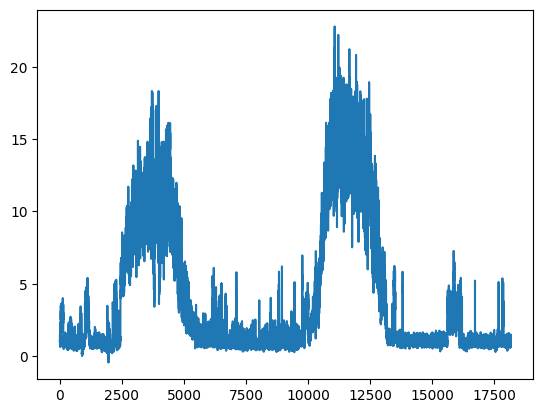

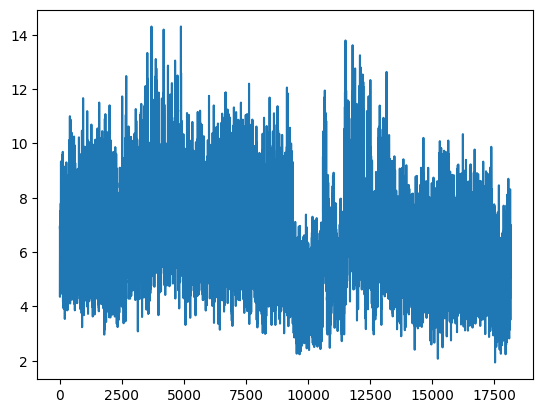

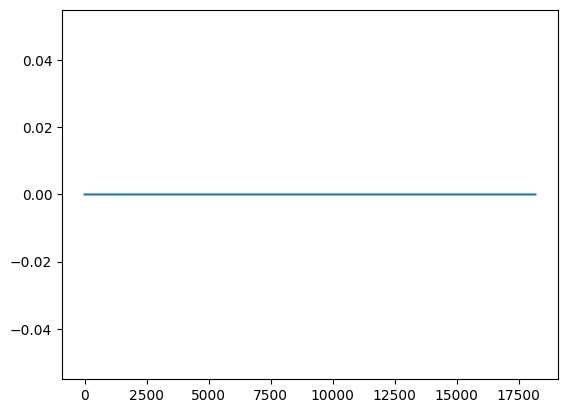

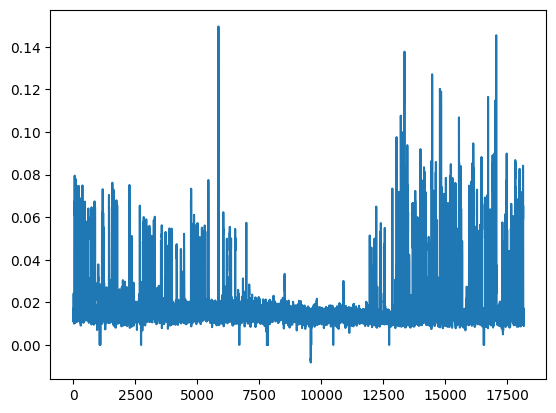

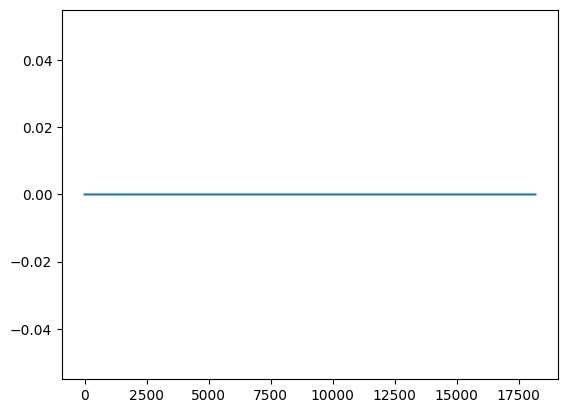

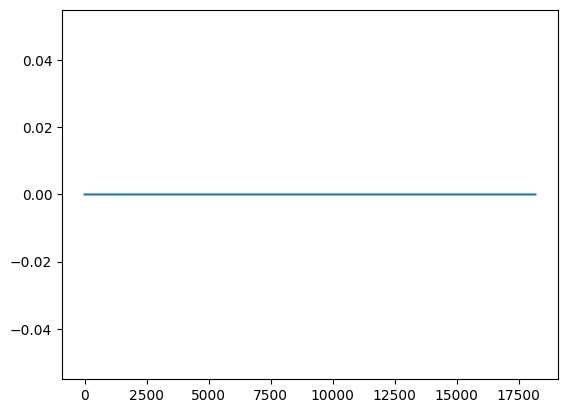

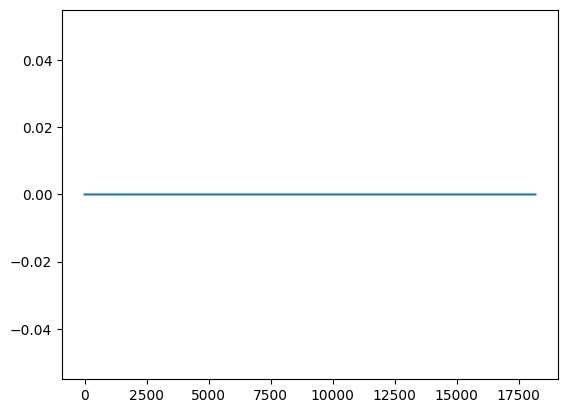

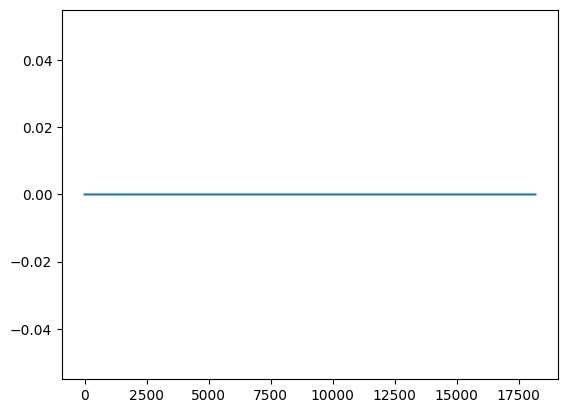

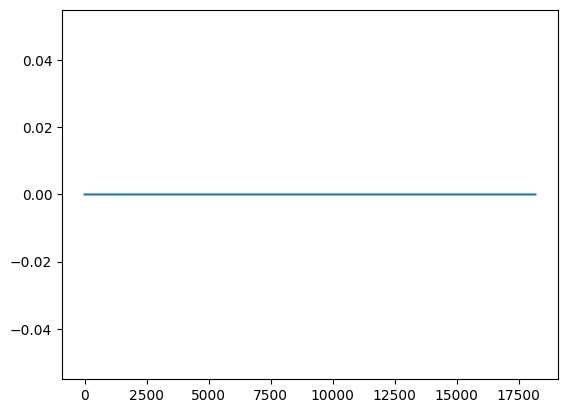

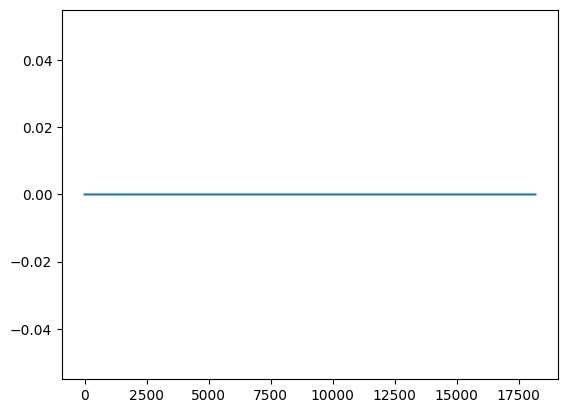

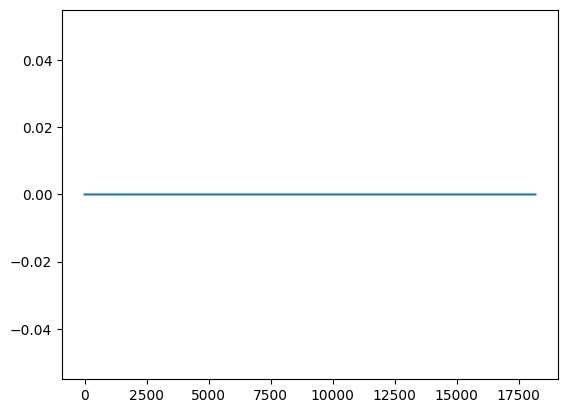

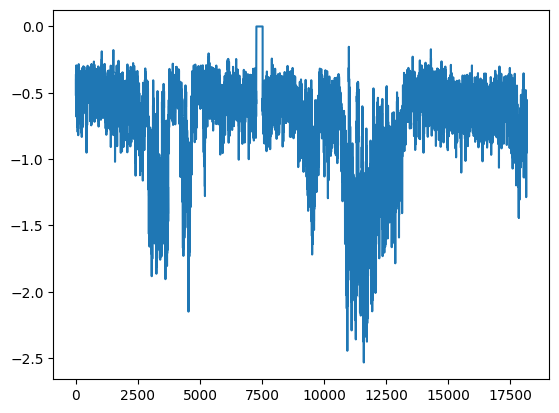

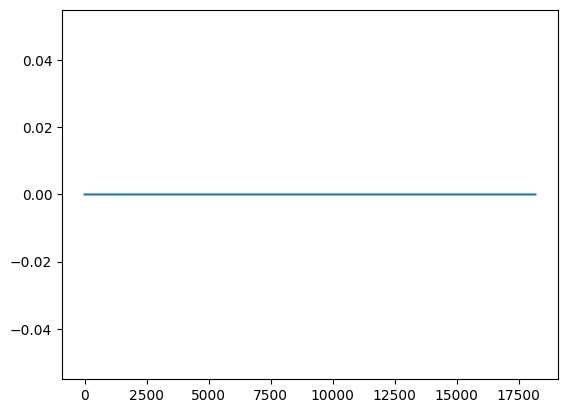

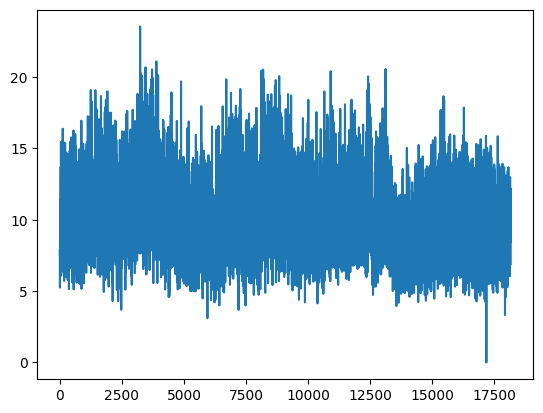

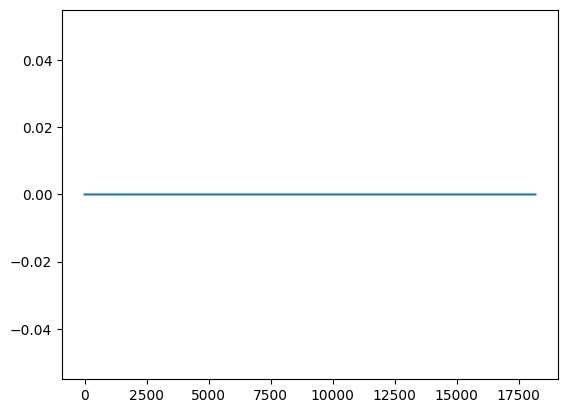

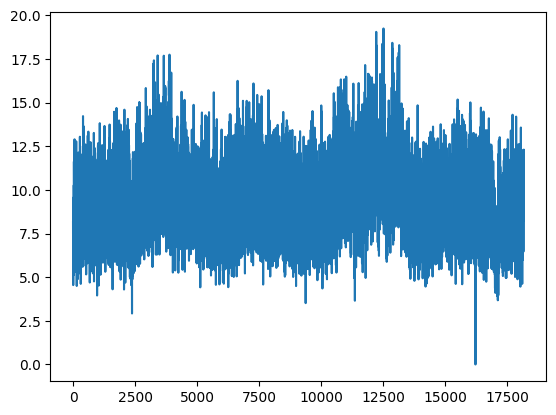

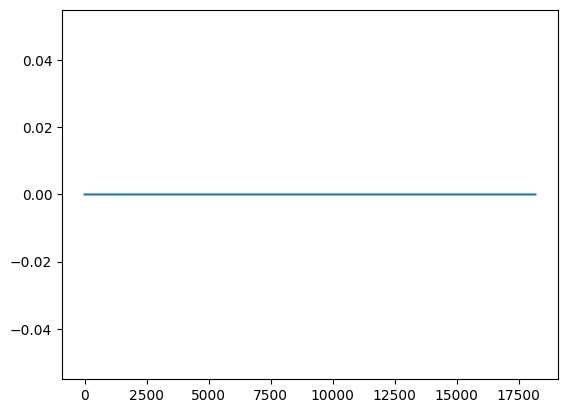

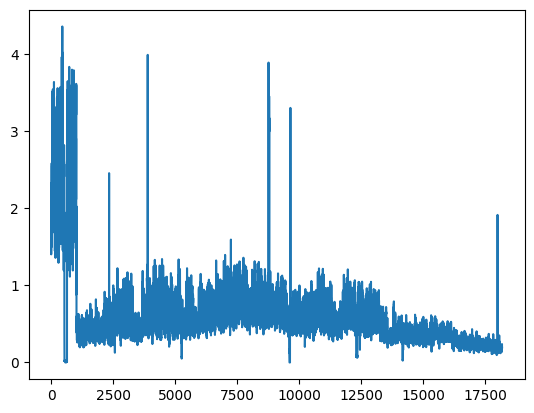

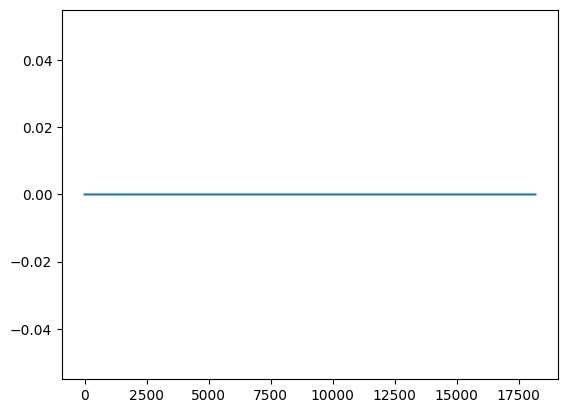

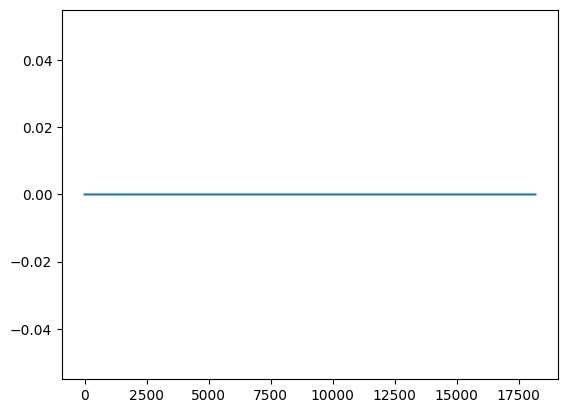

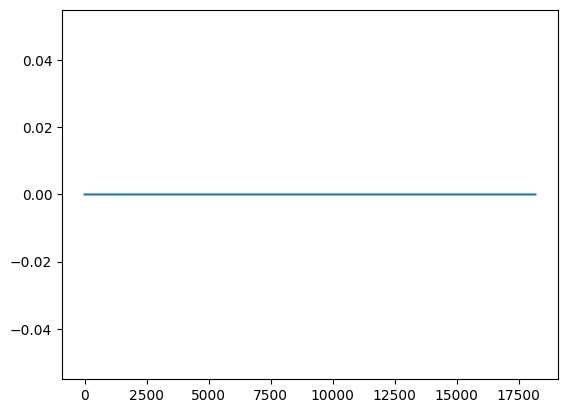

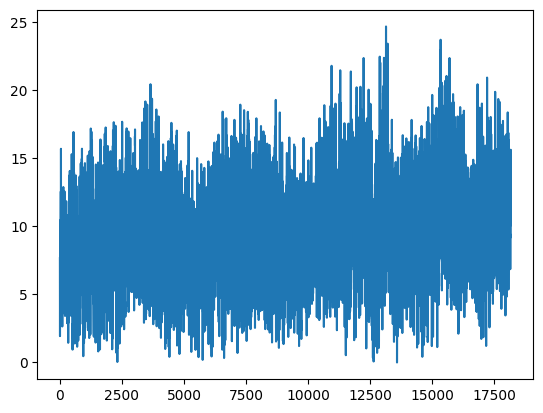

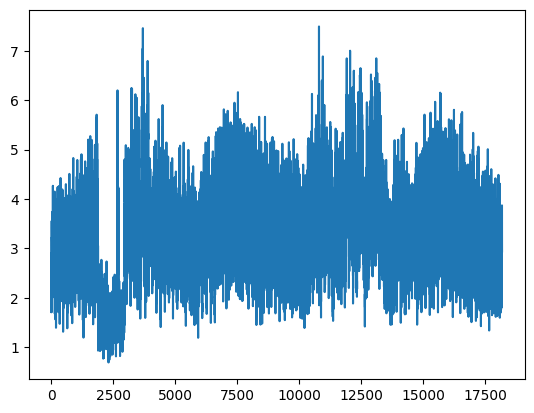

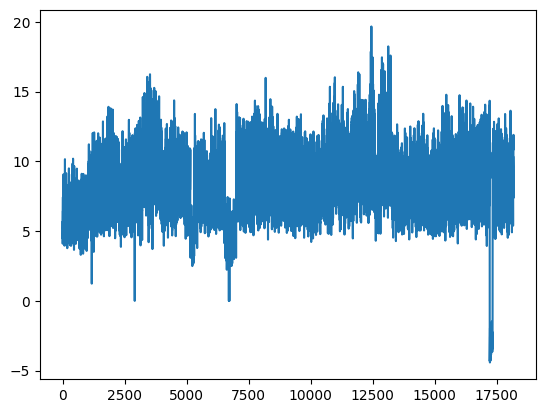

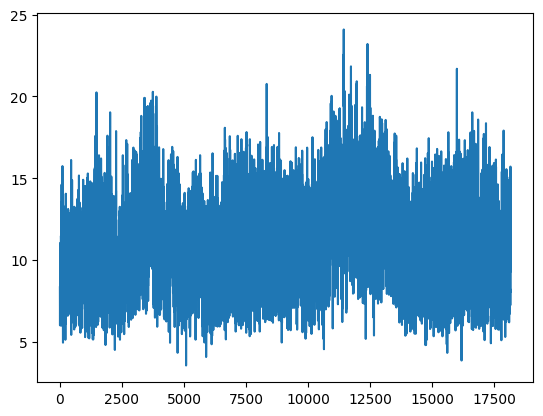

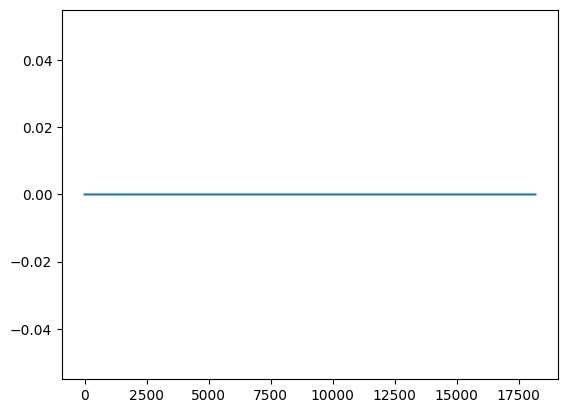

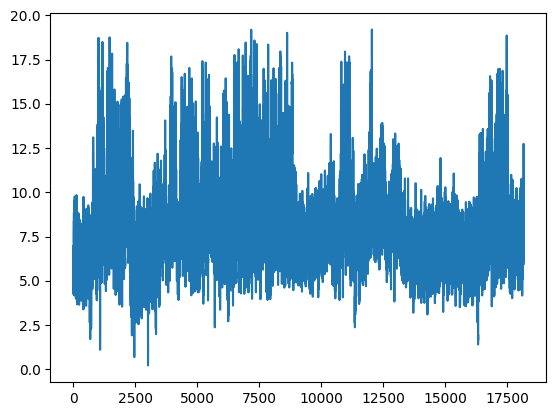

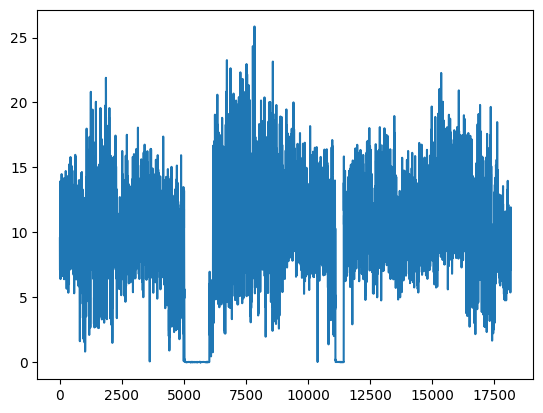

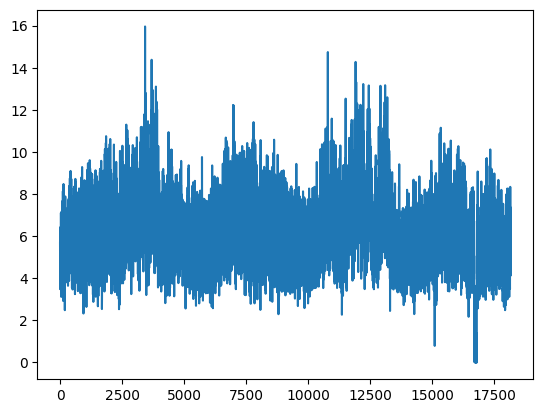

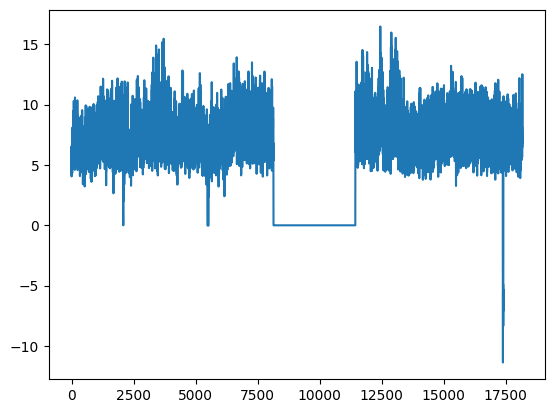

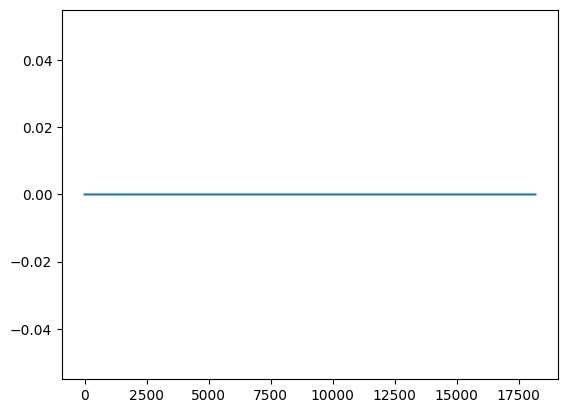

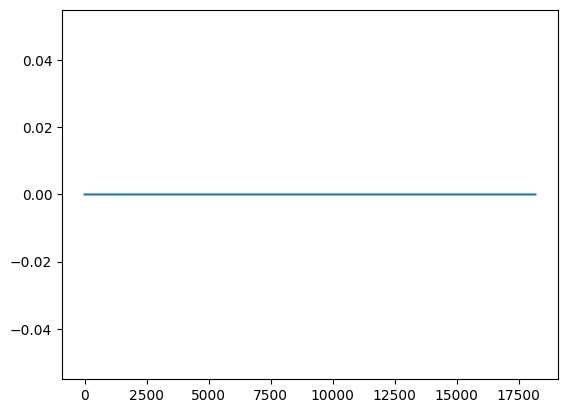

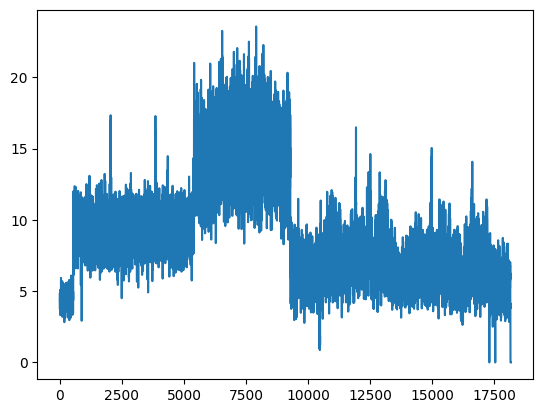

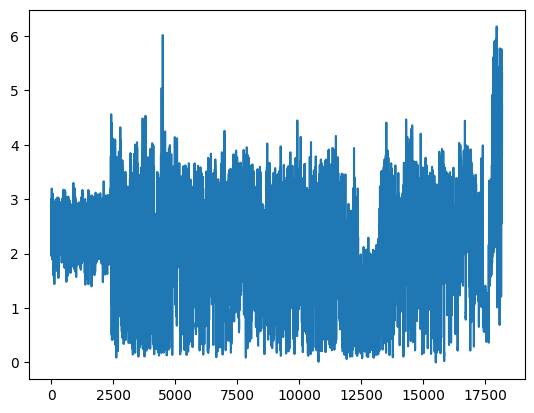

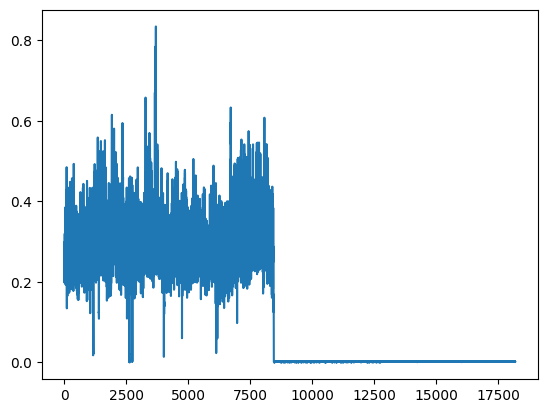

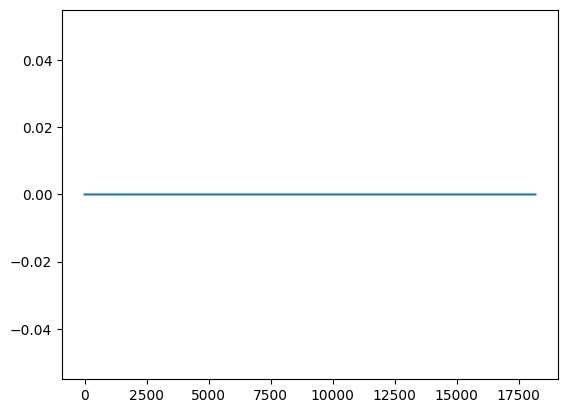

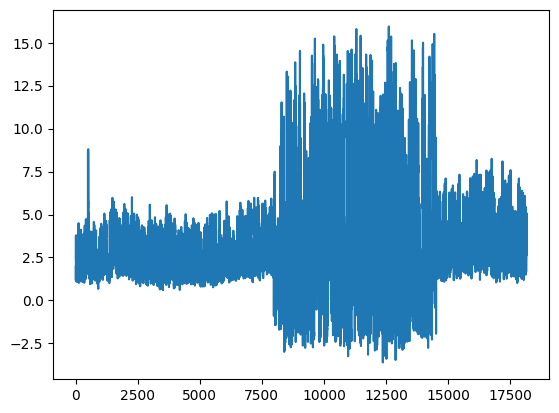

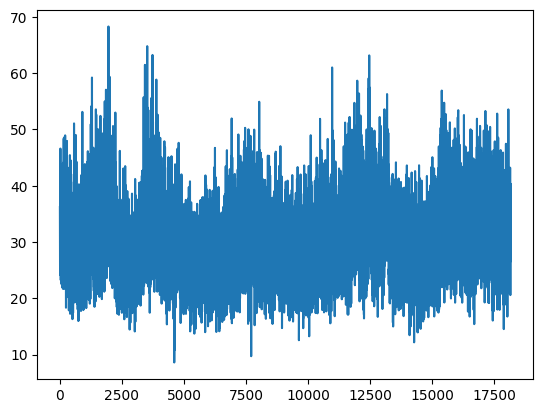

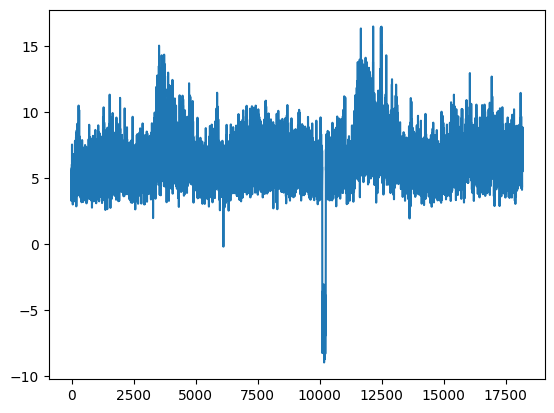

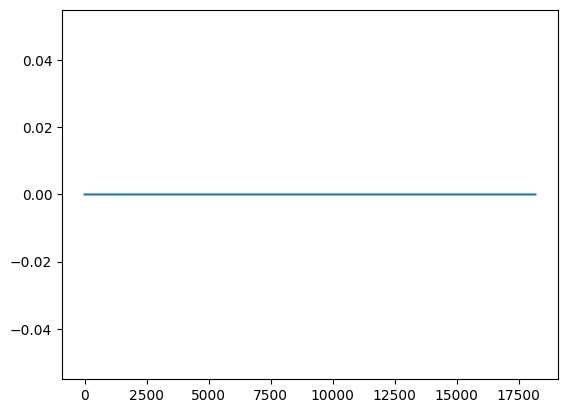

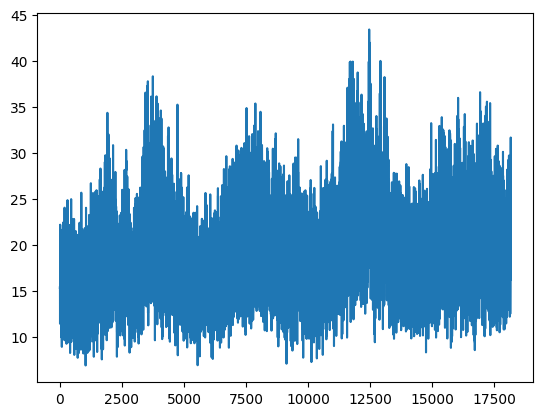

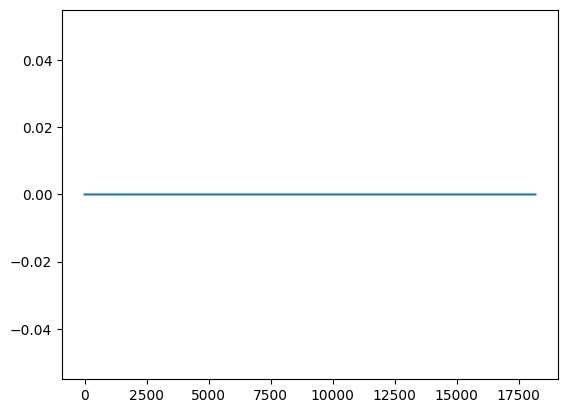

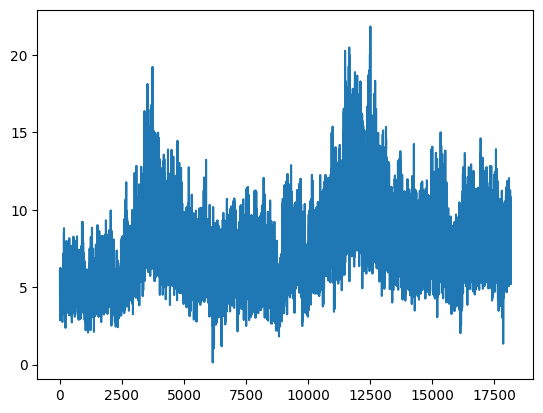

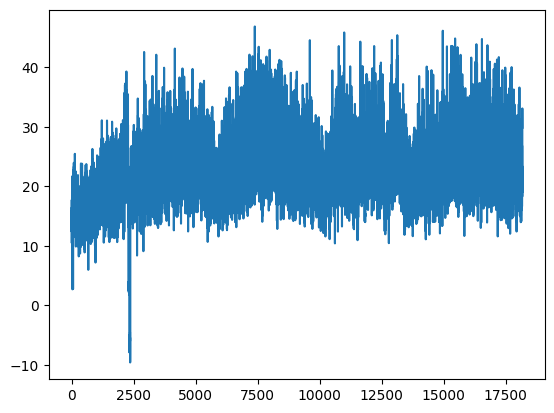

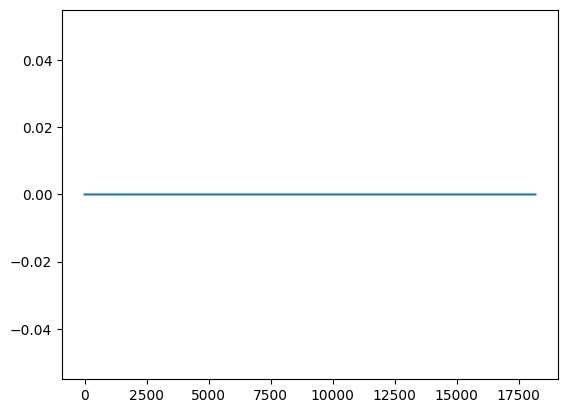

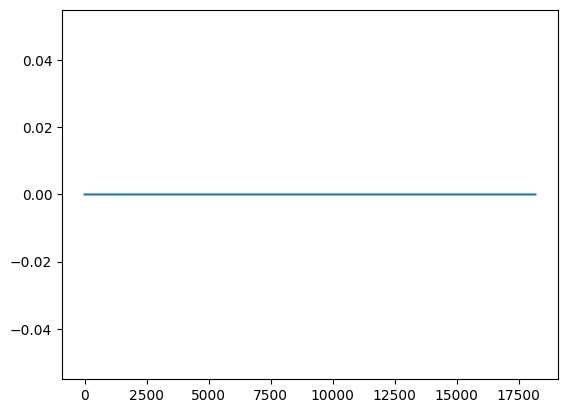

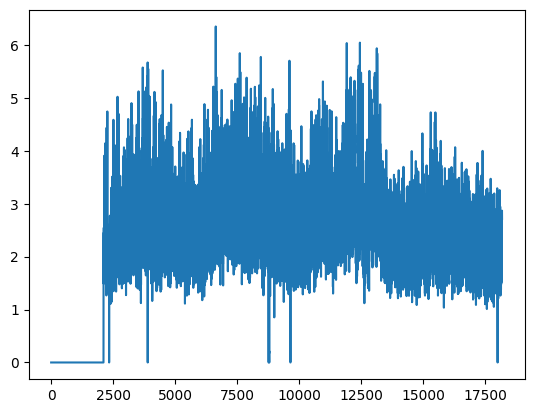

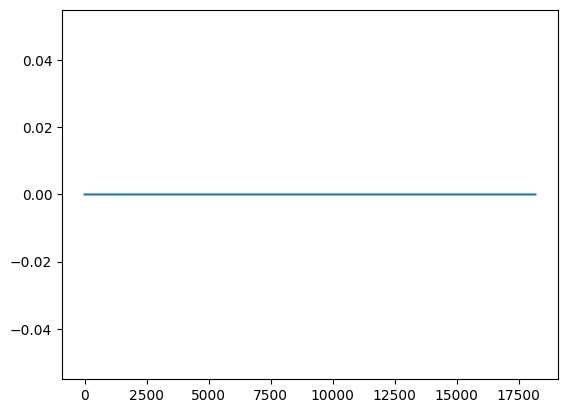

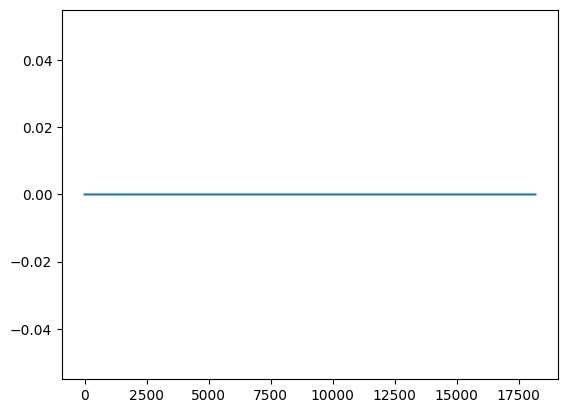

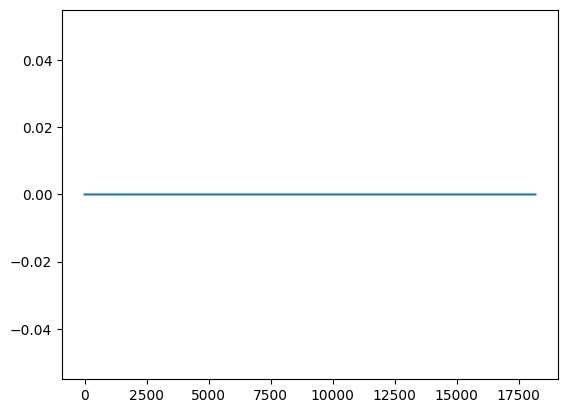

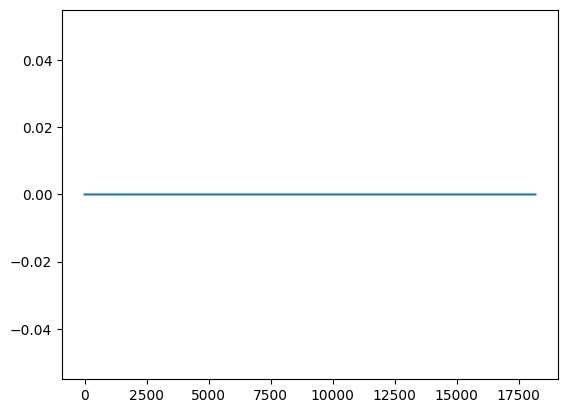

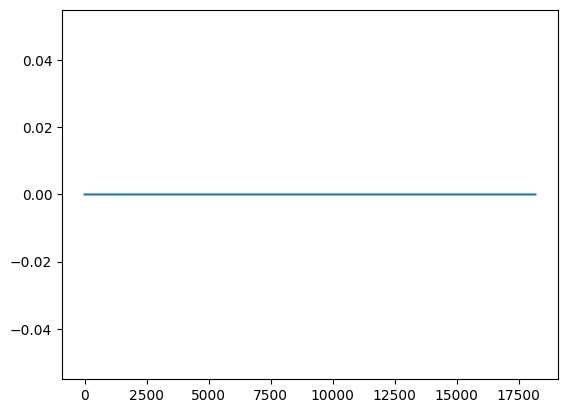

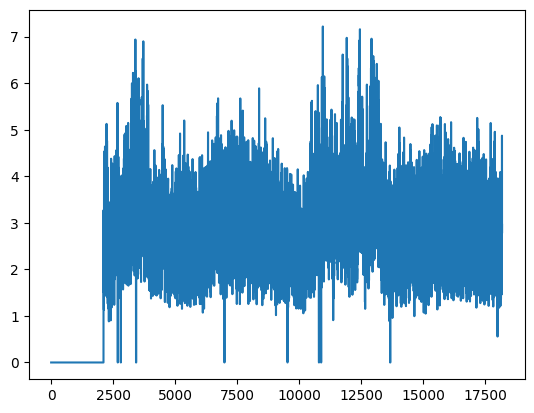

In [42]:
# plot input[:, 100, 0] vs step
import matplotlib.pyplot as plt
for i in range(107):
    plt.plot(input[:, i, 1])
    plt.show()

In [43]:
net.bus

,name,vn_kv,type,zone,in_service,min_vm_pu,max_vm_pu
101,PES150_B,150.0,b,904,True,0.9,1.1
4000,SGDE.ARG,500.0,b,4,True,0.9,1.1
4004,C.ELIA,500.0,b,4,True,0.9,1.1
90000,SU5500_B,500.0,b,901,True,0.9,1.1
90080,SJ5500_B,500.0,b,901,True,0.9,1.1
90100,MA5500_B,500.0,b,902,True,0.9,1.1
90160,BRU500_B,500.0,b,902,True,0.9,1.1
90180,CR5_500_B,500.0,b,902,True,0.9,1.1
90200,MVB500_B,500.0,b,902,True,0.9,1.1
90300,MI5500_B,500.0,b,902,True,0.9,1.1
